# An LR-RF-SVM Hybrid Approach to Cannabis Use Risk Classification Using Personality and Demographic Data

**Dataset:** UCI Drug Consumption (Quantified)  
**Target:** Cannabis (Binary: User vs Non-User)  
**Baseline Models:** Logistic Regression, Random Forest, Support Vector Machine  
**Proposed Model:** Stacking Ensemble (RF + SVM + LR base learners)  


## Step 1: Install and Import Libraries

In [ ]:
!pip install ucimlrepo shap -q

import os
import warnings
from datetime import datetime
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import shap

warnings.filterwarnings('ignore')
plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10
})



## Step 2: Load Dataset

In [ ]:
# Load from UCI repository
from ucimlrepo import fetch_ucirepo

drug_data = fetch_ucirepo(id=373)
X = drug_data.data.features
y_all = drug_data.data.targets

print('Features shape:', X.shape)
print('Targets shape:', y_all.shape)
print('\nFeature columns:')
print(X.columns.tolist())
print('\nTarget columns (drugs):')
print(y_all.columns.tolist())

Features shape: (1885, 12)
Targets shape: (1885, 19)

Feature columns:
['age', 'gender', 'education', 'country', 'ethnicity', 'nscore', 'escore', 'oscore', 'ascore', 'cscore', 'impuslive', 'ss']

Target columns (drugs):
['alcohol', 'amphet', 'amyl', 'benzos', 'caff', 'cannabis', 'choc', 'coke', 'crack', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd', 'meth', 'mushrooms', 'nicotine', 'semer', 'vsa']


## Step 3: Prepare Cannabis Target Variable

In [ ]:
# Extract cannabis column
y_cannabis = y_all['cannabis'].copy()

print('Original cannabis classes:')
print(y_cannabis.value_counts())

# Binarize:
# Non-user = CL0 (Never Used) + CL1 (Used over a Decade Ago) --> 0
# User = CL2, CL3, CL4, CL5, CL6 --> 1
y_binary = y_cannabis.apply(
    lambda x: 0 if x in ['CL0', 'CL1'] else 1
)

print('\nBinary target distribution:')
print(y_binary.value_counts())
print(f'\nNon-users (0): {(y_binary == 0).sum()} ({(y_binary == 0).mean()*100:.1f}%)')
print(f'Users (1):     {(y_binary == 1).sum()} ({(y_binary == 1).mean()*100:.1f}%)')
print('\n--- CLASS IMBALANCE NOTE ---')
print('Imbalance deliberately preserved (no oversampling applied)')
print('Weighted F1 used during CV to reduce majority class bias')
print(f'Imbalance ratio: {(y_binary==1).sum()/(y_binary==0).sum():.2f}:1 (User:Non-user)')

Original cannabis classes:
cannabis
CL6    463
CL0    413
CL2    266
CL3    211
CL1    207
CL5    185
CL4    140
Name: count, dtype: int64

Binary target distribution:
cannabis
1    1265
0     620
Name: count, dtype: int64

Non-users (0): 620 (32.9%)
Users (1):     1265 (67.1%)

--- CLASS IMBALANCE NOTE ---
Imbalance deliberately preserved (no oversampling applied)
Weighted F1 used during CV to reduce majority class bias
Imbalance ratio: 2.04:1 (User:Non-user)


## Step 4: Visualize Class Imbalance

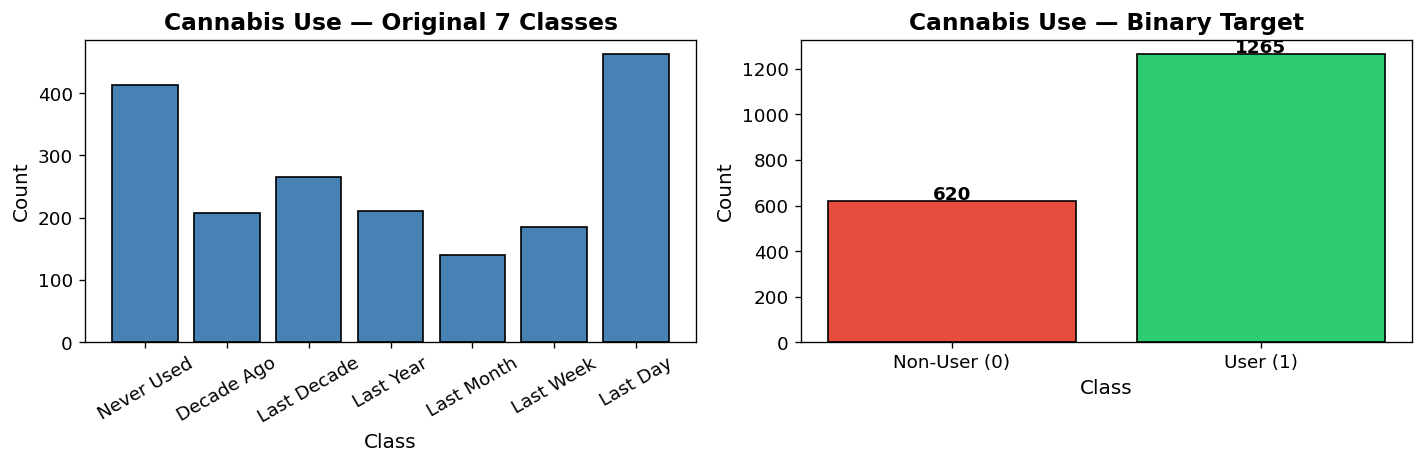

Figure saved!


In [ ]:
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_labels = ['Never Used', 'Decade Ago', 'Last Decade',
                 'Last Year', 'Last Month', 'Last Week', 'Last Day']

counts_orig = y_cannabis.value_counts().sort_index()

axes[0].bar(
    class_labels,
    counts_orig.values,
    color='steelblue',
    edgecolor='black'
)

axes[0].set_title('Cannabis Use — Original 7 Classes', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

counts_binary = y_binary.value_counts()

colors = ['#E74C3C', '#2ECC71']

axes[1].bar(
    ['Non-User (0)', 'User (1)'],
    counts_binary.sort_index().values,
    color=colors,
    edgecolor='black'
)

axes[1].set_title('Cannabis Use — Binary Target', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

for i, v in enumerate(counts_binary.sort_index().values):
    axes[1].text(
        i,
        v + 5,
        str(v),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, 'class_distribution.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Figure saved!')

## Step 5: Train-Test Split and Feature Scaling

In [ ]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Feature scaling — CRITICAL for SVM
# SVM is sensitive to feature scale because it computes distances
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(
    scaler,
    os.path.join(MODEL_DIR, "standard_scaler.pkl")
)

print("Scaler saved!")

print('\nFeature scaling applied (StandardScaler)')
print('numeric ranges would dominate the margin calculation.')

Training set: 1508 samples
Test set:     377 samples
Scaler saved!

Feature scaling applied (StandardScaler)
numeric ranges would dominate the margin calculation.


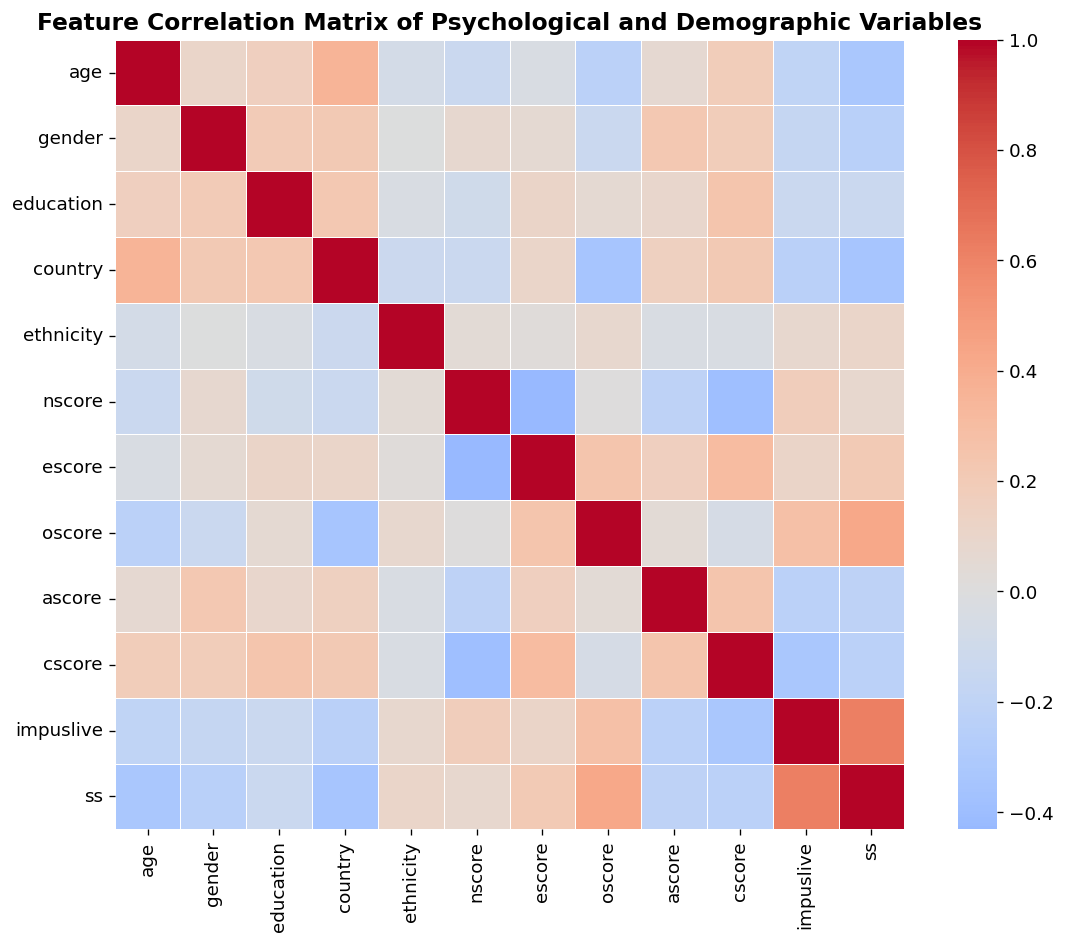

Highly correlated feature pairs (|r| > 0.30):
age ↔ country: 0.354
age ↔ ss: -0.332
country ↔ oscore: -0.342
country ↔ ss: -0.345
nscore ↔ escore: -0.431
nscore ↔ cscore: -0.391
escore ↔ cscore: 0.308
oscore ↔ ss: 0.422
cscore ↔ impuslive: -0.335
impuslive ↔ ss: 0.623


In [ ]:
# Feature Correlation Analysis

plt.figure(figsize=(10, 8))

corr_matrix = X.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    'Feature Correlation Matrix of Psychological and Demographic Variables',
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, 'feature_correlation_matrix.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Highly correlated feature pairs (|r| > 0.30):')

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) > 0.30:

            print(
                f'{corr_matrix.columns[i]} ↔ '
                f'{corr_matrix.columns[j]}: '
                f'{corr_val:.3f}'
            )


## Step 6: Hyperparameter Tuning with 5-Fold Cross Validation


In [ ]:
## Step 6: Hyperparameter Tuning with 5-Fold Cross Validation

# 5-fold stratified cross-validation
TABLE_DIR = "tables"
os.makedirs(TABLE_DIR, exist_ok=True)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#LR
print("\nTuning Logistic Regression...")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42
    ),
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

lr_model = grid_lr.best_estimator_

print("=== LR BEST HYPERPARAMETERS ===")
print(grid_lr.best_params_)

#RF
print("\nTuning Random Forest...")

param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [5, 8, 10],
    'min_samples_split': [10, 20],
    'min_samples_leaf':  [4, 8, 12],
    'max_features':      ['sqrt'],
    'class_weight':      ['balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

grid_rf.fit(X_train_scaled, y_train)

rf_model = grid_rf.best_estimator_

print("=== RF BEST HYPERPARAMETERS ===")
print(grid_rf.best_params_)

print(f"Best 5-Fold CV Score: {grid_rf.best_score_:.4f}")

#SVM
print("\nTuning SVM...")

param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(
    estimator=SVC(
        probability=True,
        random_state=42
    ),
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

svm_model = grid_svm.best_estimator_

print("=== SVM BEST HYPERPARAMETERS ===")
print(grid_svm.best_params_)

joblib.dump(
    lr_model,
    os.path.join(MODEL_DIR, "logistic_regression.pkl")
)

joblib.dump(
    rf_model,
    os.path.join(MODEL_DIR, "random_forest.pkl")
)

joblib.dump(
    svm_model,
    os.path.join(MODEL_DIR, "svm.pkl")
)

print("All trained models saved successfully!")

best_params = {
    "Logistic Regression": grid_lr.best_params_,
    "Random Forest": grid_rf.best_params_,
    "SVM": grid_svm.best_params_
}

best_params_df = pd.DataFrame(best_params).T

best_params_df.to_csv(
    os.path.join(TABLE_DIR, "best_hyperparameters.csv")
)

print("Best hyperparameters saved!")


Tuning Logistic Regression...
=== LR BEST HYPERPARAMETERS ===
{'C': 0.1, 'solver': 'lbfgs'}

Tuning Random Forest...
=== RF BEST HYPERPARAMETERS ===
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 200}
Best 5-Fold CV Score: 0.8182

Tuning SVM...
=== SVM BEST HYPERPARAMETERS ===
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
All trained models saved successfully!
Best hyperparameters saved!


## Step 7: Final Evaluation on Held-Out Test Set


In [ ]:
## Step 7
models = {'SVM': svm_model, 'Logistic Regression': lr_model, 'Random Forest': rf_model}
y_preds = {name: model.predict(X_test_scaled) for name, model in models.items()}
train_preds = {name: model.predict(X_train_scaled) for name, model in models.items()}

summary_rows = []
for name, model in models.items():
    test_pred = y_preds[name]
    train_pred = train_preds[name]

    test_acc = accuracy_score(y_test, test_pred)
    test_prec = classification_report(y_test, test_pred, output_dict=True)['1']['precision']
    test_rec = classification_report(y_test, test_pred, output_dict=True)['1']['recall']
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])

    test_f1 = f1_score(y_test, test_pred, average='weighted')
    train_f1 = f1_score(y_train, train_pred, average='weighted')
    gap = train_f1 - test_f1

    sv = sum(model.n_support_) if name == 'SVM' else "N/A"

    summary_rows.append({
        'Model': name,
        'Accuracy': round(test_acc, 4),
        'Precision (User)': round(test_prec, 4),
        'Recall (User)': round(test_rec, 4),
        'AUC-ROC': round(test_auc, 4),
        'Train F1': round(train_f1, 4),
        'Test F1': round(test_f1, 4),
        'F1 Gap': round(gap, 4),
        'Support Vectors': sv
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(
    os.path.join(TABLE_DIR, "model_performance_summary.csv"),
    index=False
)

print("Performance summary saved!")
print('\n=== COMPREHENSIVE 5-MODEL RESULTS & OVERFITTING ANALYSIS ===')
print(df_summary.to_string(index=False))


Performance summary saved!

=== COMPREHENSIVE 5-MODEL RESULTS & OVERFITTING ANALYSIS ===
              Model  Accuracy  Precision (User)  Recall (User)  AUC-ROC  Train F1  Test F1  F1 Gap Support Vectors
                SVM    0.8037            0.8377         0.8775   0.8555    0.8461   0.8010  0.0451             661
Logistic Regression    0.7984            0.8391         0.8656   0.8634    0.8261   0.7966  0.0295             N/A
      Random Forest    0.7931            0.8755         0.8063   0.8651    0.8791   0.7966  0.0825             N/A


## Step 8: Proposed Model - Stacking Ensemble


STEP 8: TRAINING STACKING ENSEMBLE
Stacking model trained successfully!

Optimizing decision threshold (OOF validation)...
Optimal threshold: 0.4556

PROPOSED STACKING RESULTS

              precision    recall  f1-score   support

    Non-User       0.81      0.64      0.71       124
        User       0.84      0.92      0.88       253

    accuracy                           0.83       377
   macro avg       0.82      0.78      0.80       377
weighted avg       0.83      0.83      0.82       377


PROPOSED MODEL SUMMARY 

                                     Model  Accuracy  Precision (User)  Recall (User)  AUC-ROC  Train F1  Test F1  F1 Gap  Decision Threshold
Stacking Ensemble (Gradient Boosting Meta)    0.8302            0.8387         0.9249   0.8684    0.8462   0.8244  0.0218              0.4556

FINAL COMPARISON TABLE

                                     Model  Accuracy  Precision (User)  Recall (User)  AUC-ROC  Train F1  Test F1  F1 Gap Support Vectors  Decision Threshold
  

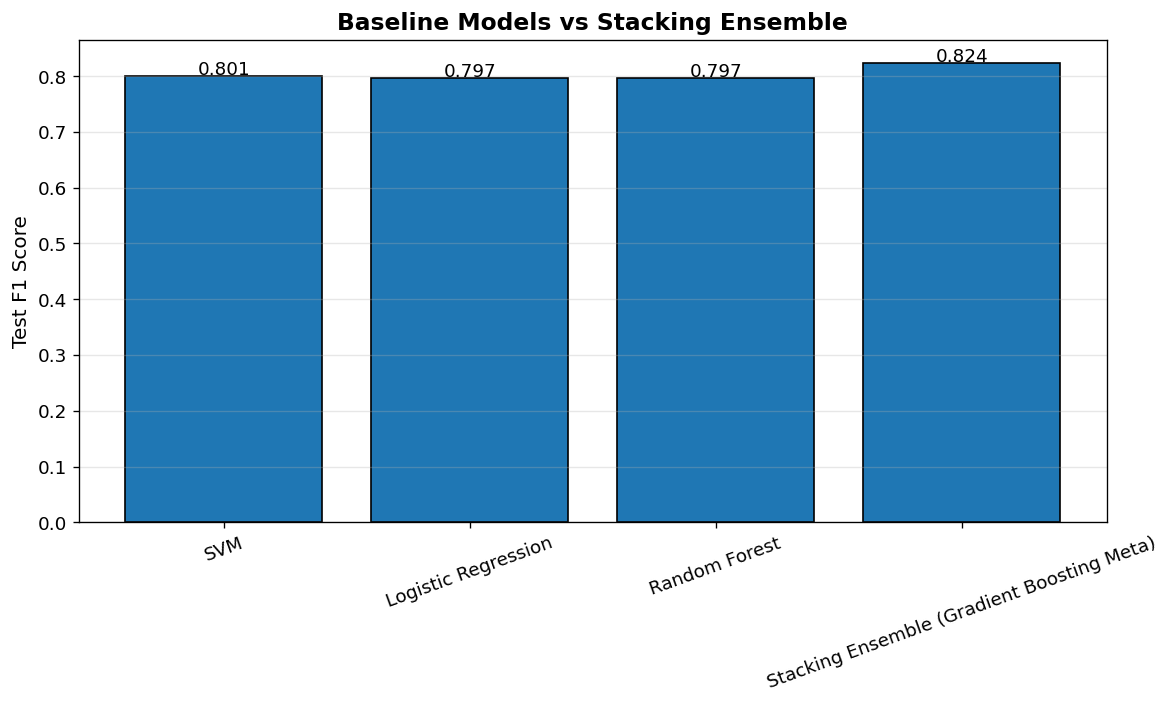


Step 8 completed successfully!
Stacking model and optimal threshold saved successfully to the models directory!


In [ ]:
## Step 8: Proposed Model - Stacking Ensemble (Final Model)

print("\nSTEP 8: TRAINING STACKING ENSEMBLE")

base_learners = [
    ('lr', lr_model),
    ('rf', rf_model),
    ('svm', svm_model)
]

meta_learner = GradientBoostingClassifier(
    random_state=42
)

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    stack_method='predict_proba',
    passthrough=True,
    cv=cv_strategy,
    n_jobs=-1
)

param_grid_stack = {
    'final_estimator__n_estimators': [30, 50, 100],
    'final_estimator__learning_rate': [0.05, 0.1],
    'final_estimator__max_depth': [2, 3]
}

grid_stack = GridSearchCV(
    estimator=stacking_model,
    param_grid=param_grid_stack,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_stack.fit(X_train_scaled, y_train)

stacking_model = grid_stack.best_estimator_

print("Stacking model trained successfully!")

print("\nOptimizing decision threshold (OOF validation)...")

oof_probs = cross_val_predict(
    stacking_model,
    X_train_scaled,
    y_train,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    oof_probs
)

f1_scores = 2 * (
    precisions * recalls
) / (
    precisions + recalls + 1e-10
)

optimal_idx = np.argmax(f1_scores[:-1])

optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")

test_probs = stacking_model.predict_proba(
    X_test_scaled
)[:, 1]

train_probs = stacking_model.predict_proba(
    X_train_scaled
)[:, 1]

y_test_pred = (
    test_probs >= optimal_threshold
).astype(int)

y_train_pred = (
    train_probs >= optimal_threshold
).astype(int)

print("\nPROPOSED STACKING RESULTS\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=['Non-User', 'User']
    )
)

test_acc = accuracy_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    test_probs
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted'
)

train_f1 = f1_score(
    y_train,
    y_train_pred,
    average='weighted'
)

gap = train_f1 - test_f1

report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True
)

stacking_summary = pd.DataFrame([{
    'Model': 'Stacking Ensemble (Gradient Boosting Meta)',
    'Accuracy': round(test_acc, 4),
    'Precision (User)': round(report['1']['precision'], 4),
    'Recall (User)': round(report['1']['recall'], 4),
    'AUC-ROC': round(test_auc, 4),
    'Train F1': round(train_f1, 4),
    'Test F1': round(test_f1, 4),
    'F1 Gap': round(gap, 4),
    'Decision Threshold': round(optimal_threshold, 4)
}])

print("\nPROPOSED MODEL SUMMARY \n")

print(
    stacking_summary.to_string(index=False)
)

final_df = pd.concat(
    [df_summary, stacking_summary],
    ignore_index=True
)

final_df.to_csv(
    os.path.join(TABLE_DIR, "final_model_comparison.csv"),
    index=False
)

print("\nFINAL COMPARISON TABLE\n")

print(
    final_df.to_string(index=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    final_df['Model'],
    final_df['Test F1'],
    edgecolor='black'
)

plt.title(
    "Baseline Models vs Stacking Ensemble",
    fontweight='bold'
)

plt.ylabel("Test F1 Score")

plt.xticks(rotation=20)

plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(final_df['Test F1']):

    plt.text(
        i,
        v + 0.002,
        f"{v:.3f}",
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "final_model_comparison.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nStep 8 completed successfully!")

joblib.dump(
    stacking_model,
    os.path.join(MODEL_DIR, "standard_stacking_model.pkl")
)

joblib.dump(
    optimal_threshold,
    os.path.join(MODEL_DIR, "standard_stacking_threshold.pkl")
)

print(
    "Stacking model and optimal threshold saved successfully to the models directory!"
)

## Step 9: Visualization: Train vs Test F1 Comparison

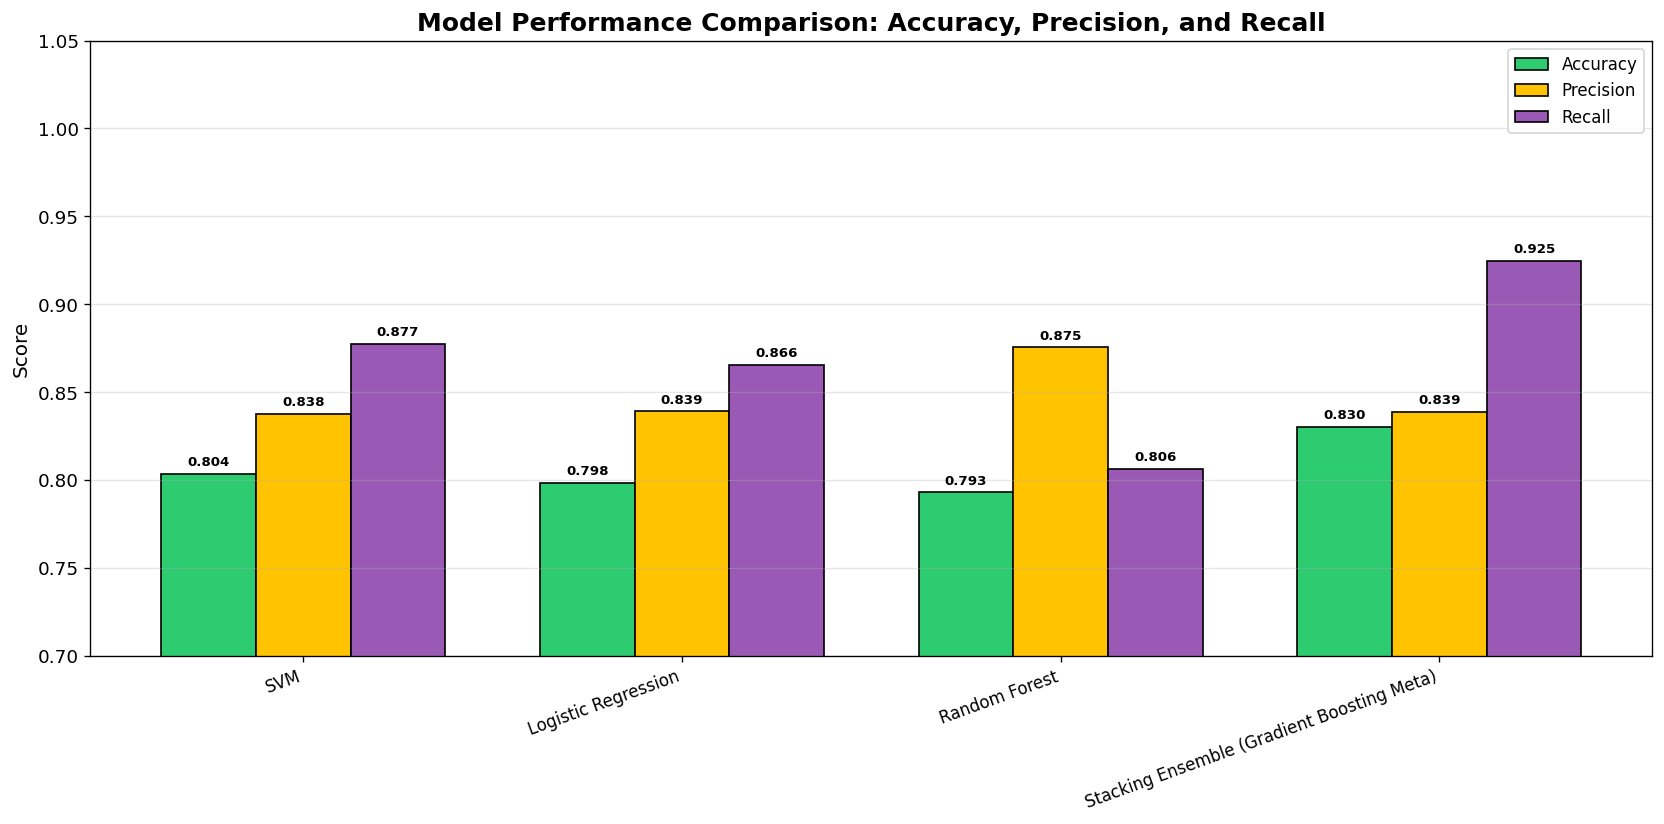

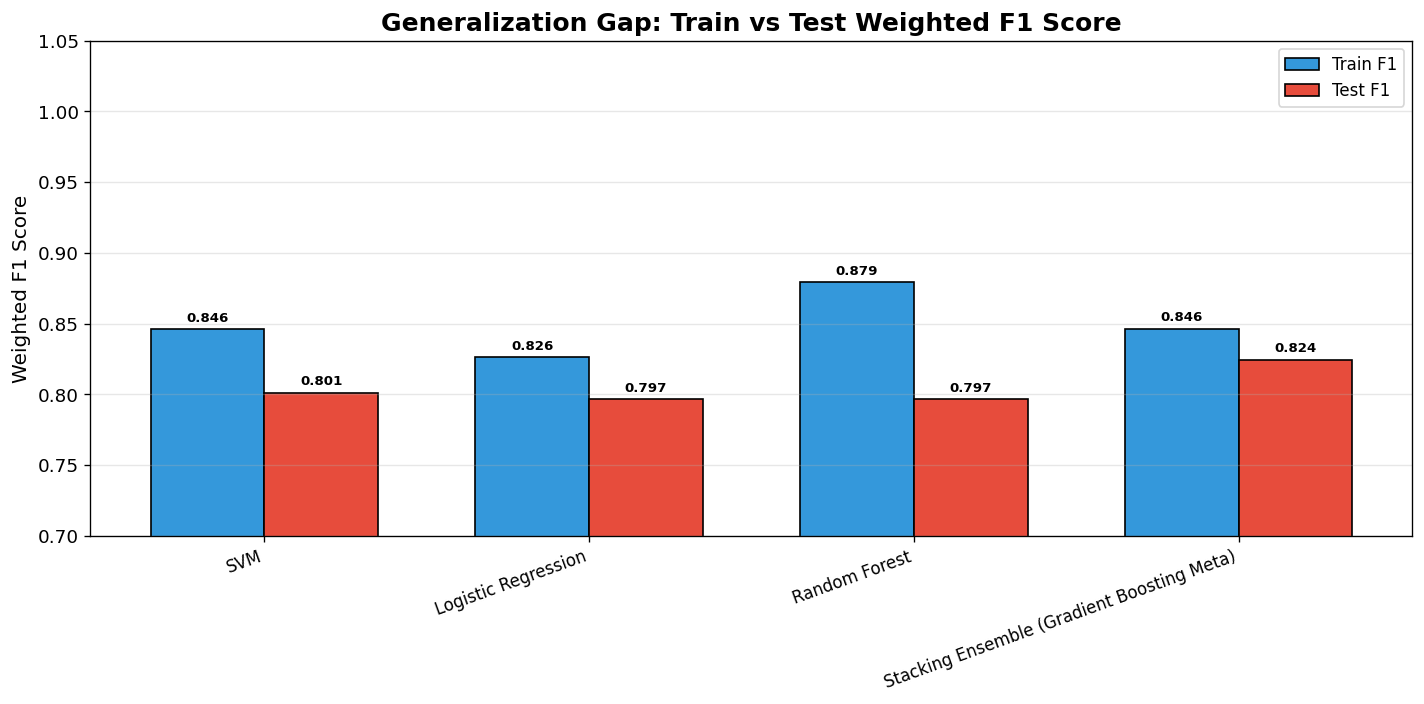


Performance comparison visualizations completed successfully!


In [ ]:
# Visualization


fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(final_df))
width = 0.25

# Bars
bars_acc = ax.bar(
    x - width,
    final_df['Accuracy'],
    width,
    label='Accuracy',
    color='#2ECC71',
    edgecolor='black'
)

bars_prec = ax.bar(
    x,
    final_df['Precision (User)'],
    width,
    label='Precision',
    color='#FFC300',
    edgecolor='black'
)

bars_rec = ax.bar(
    x + width,
    final_df['Recall (User)'],
    width,
    label='Recall',
    color='#9B59B6',
    edgecolor='black'
)

# Formatting
ax.set_title(
    "Model Performance Comparison: Accuracy, Precision, and Recall",
    fontweight='bold',
    fontsize=15
)

ax.set_ylabel("Score", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(
    final_df['Model'],
    rotation=20,
    ha='right',
    fontsize=10
)

ax.set_ylim(0.70, 1.05)

ax.legend(loc='upper right')

ax.grid(axis='y', alpha=0.3)

# Labels
for container in [bars_acc, bars_prec, bars_rec]:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=8,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "accuracy_precision_recall_comparison.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Visualization 2:
# Train vs Test Weighted F1 Score

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35

bars1 = ax.bar(
    x - width/2,
    final_df['Train F1'],
    width,
    label='Train F1',
    color='#3498db',
    edgecolor='black'
)

bars2 = ax.bar(
    x + width/2,
    final_df['Test F1'],
    width,
    label='Test F1',
    color='#e74c3c',
    edgecolor='black'
)

# Formatting
ax.set_title(
    "Generalization Gap: Train vs Test Weighted F1 Score",
    fontweight='bold',
    fontsize=15
)

ax.set_ylabel("Weighted F1 Score", fontsize=12)

ax.set_xticks(x)

ax.set_xticklabels(
    final_df['Model'],
    rotation=20,
    ha='right',
    fontsize=10
)

ax.set_ylim(0.70, 1.05)

ax.legend(loc='upper right')

ax.grid(axis='y', alpha=0.3)

# Labels
for container in [bars1, bars2]:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=8,
        fontweight='bold'
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "train_vs_test_f1_comparison.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nPerformance comparison visualizations completed successfully!")

## Step 11: SHAP Analysis — Feature Importance

In [ ]:
## Step 11: SHAP Analysis for Both Models
print('Computing SHAP values...')
feature_names = X.columns.tolist()
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
X_sample = X_test_df.iloc[:50]

# SVM SHAP
background = shap.sample(pd.DataFrame(X_train_scaled, columns=feature_names), 100)
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, background)
shap_values_svm = explainer_svm.shap_values(X_sample, nsamples=100)

# LR SHAP
explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_sample)



# RF
shap_values_rf = shap.TreeExplainer(rf_model).shap_values(X_sample)

print('SHAP values computed!')

Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

SHAP values computed!


# Step 12: Cross-Model SHAP Feature Importance



=== CROSS-MODEL SHAP FEATURE IMPORTANCE ===
Normalizing baseline SHAP importance scores...

Computing SHAP values for proposed stacking ensemble...


  0%|          | 0/50 [00:00<?, ?it/s]

Stacking SHAP computation completed!

=== CROSS-MODEL FEATURE IMPORTANCE ===

  Feature    SVM  Logistic Regression  Random Forest  Hybrid Stacking Ensemble  Average Importance
  country 0.2320               0.2537         0.2469                    0.2433              0.2439
      age 0.2236               0.1945         0.1683                    0.2003              0.1967
   oscore 0.1292               0.1356         0.1105                    0.1254              0.1252
       ss 0.0793               0.0794         0.1616                    0.1160              0.1091
   cscore 0.0871               0.0697         0.0840                    0.0828              0.0809
education 0.0585               0.0629         0.0683                    0.0695              0.0648
   gender 0.0658               0.0691         0.0534                    0.0571              0.0614
impuslive 0.0228               0.0300         0.0454                    0.0345              0.0332
   escore 0.0323               

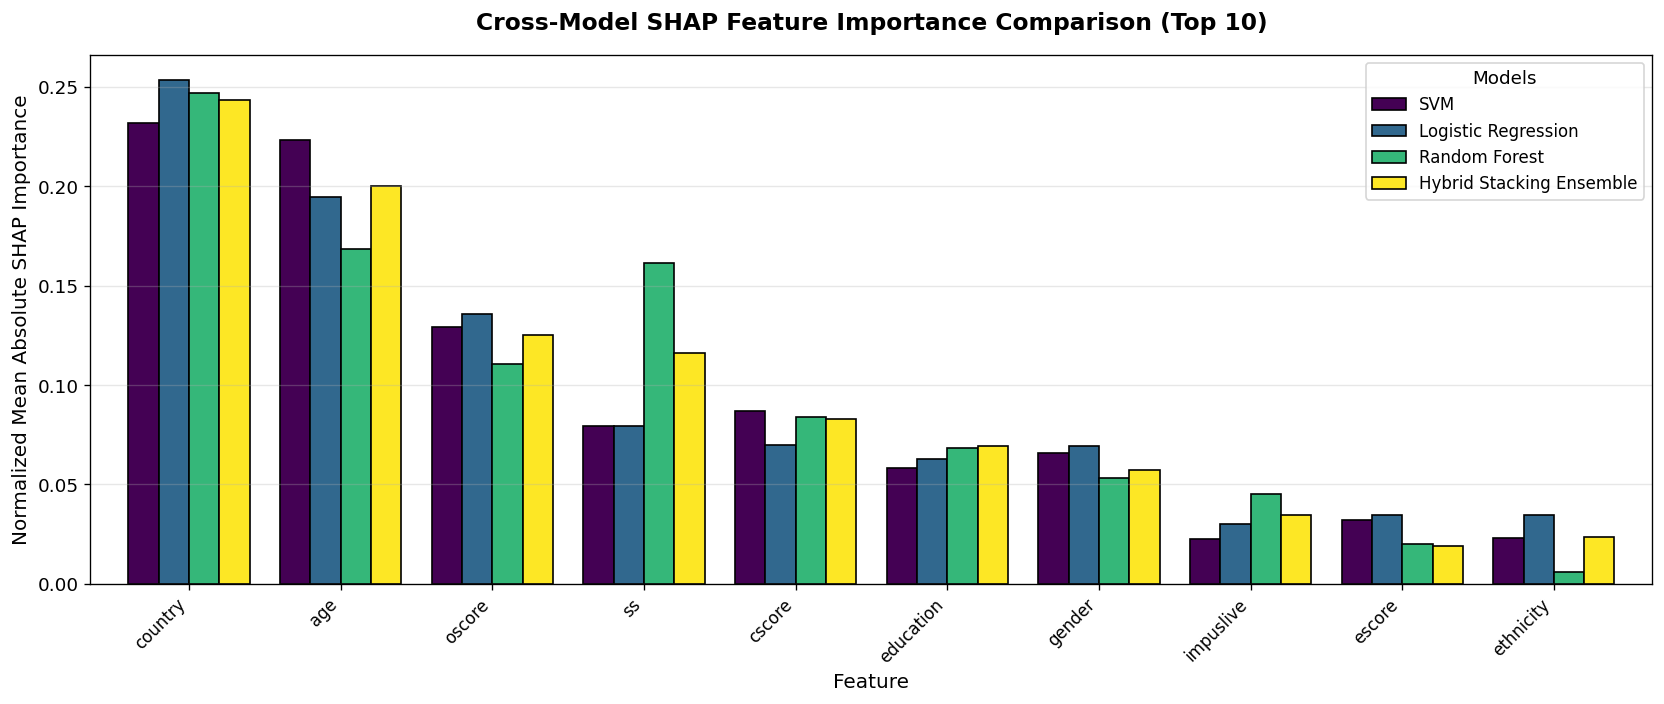


Cross-model SHAP analysis completed successfully!


In [ ]:
# Step 12: Cross-Model SHAP Feature Importance
print("\n=== CROSS-MODEL SHAP FEATURE IMPORTANCE ===")

def get_mean_shap(shap_values):
    """
    Safely extract mean absolute SHAP importance
    regardless of SHAP explainer type.
    """

    if isinstance(shap_values, list):
        vals = shap_values[1]

    elif hasattr(shap_values, 'values'):
        vals = shap_values.values

    else:
        vals = np.array(shap_values)

    if vals.ndim == 3:
        vals = vals[:, :, 1]

    return np.abs(vals).mean(axis=0).flatten()


def normalize_importance(arr):
    return arr / (arr.sum() + 1e-10)

print("Normalizing baseline SHAP importance scores...")

svm_importance = normalize_importance(
    get_mean_shap(shap_values_svm)
)

lr_importance = normalize_importance(
    get_mean_shap(shap_values_lr)
)

rf_importance = normalize_importance(
    get_mean_shap(shap_values_rf)
)


print("\nComputing SHAP values for proposed stacking ensemble...")

background_stack = shap.sample(
    pd.DataFrame(X_train_scaled, columns=feature_names),
    100,
    random_state=42
)

explainer_stack = shap.KernelExplainer(
    stacking_model.predict_proba,
    background_stack
)

shap_values_stack = explainer_stack.shap_values(
    X_sample,
    nsamples=100
)

stacking_importance = normalize_importance(
    get_mean_shap(shap_values_stack)
)

print("Stacking SHAP computation completed!")

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SVM': svm_importance,
    'Logistic Regression': lr_importance,
    'Random Forest': rf_importance,
    'Hybrid Stacking Ensemble': stacking_importance
})

importance_df['Average Importance'] = importance_df[
    [
        'SVM',
        'Logistic Regression',
        'Random Forest',
        'Hybrid Stacking Ensemble'
    ]
].mean(axis=1)

importance_df = importance_df.sort_values(
    by='Average Importance',
    ascending=False
)

importance_df.to_csv(
    os.path.join(
        TABLE_DIR,
        "cross_model_feature_importance.csv"
    ),
    index=False
)

print("\n=== CROSS-MODEL FEATURE IMPORTANCE ===\n")
print(importance_df.round(4).to_string(index=False))


top_features = importance_df.head(10)

plot_df = top_features.set_index('Feature')[
    [
        'SVM',
        'Logistic Regression',
        'Random Forest',
        'Hybrid Stacking Ensemble'
    ]
]

ax = plot_df.plot(
    kind='bar',
    figsize=(14, 6),
    width=0.8,
    edgecolor='black',
    colormap='viridis'
)

plt.title(
    'Cross-Model SHAP Feature Importance Comparison (Top 10)',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.ylabel(
    'Normalized Mean Absolute SHAP Importance',
    fontsize=12
)

plt.xlabel(
    'Feature',
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.legend(title='Models')

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        'cross_model_feature_importance.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nCross-model SHAP analysis completed successfully!")

# Step 13: SHAP Bar Plot (Baselines + Hybrid Ensemble)



=== COMPUTING HYBRID ENSEMBLE SHAP VALUES ===
Please wait... this may take a few minutes...


  0%|          | 0/50 [00:00<?, ?it/s]

Stacking SHAP values computed!

=== GENERATING 2x2 SHAP BAR PLOTS ===


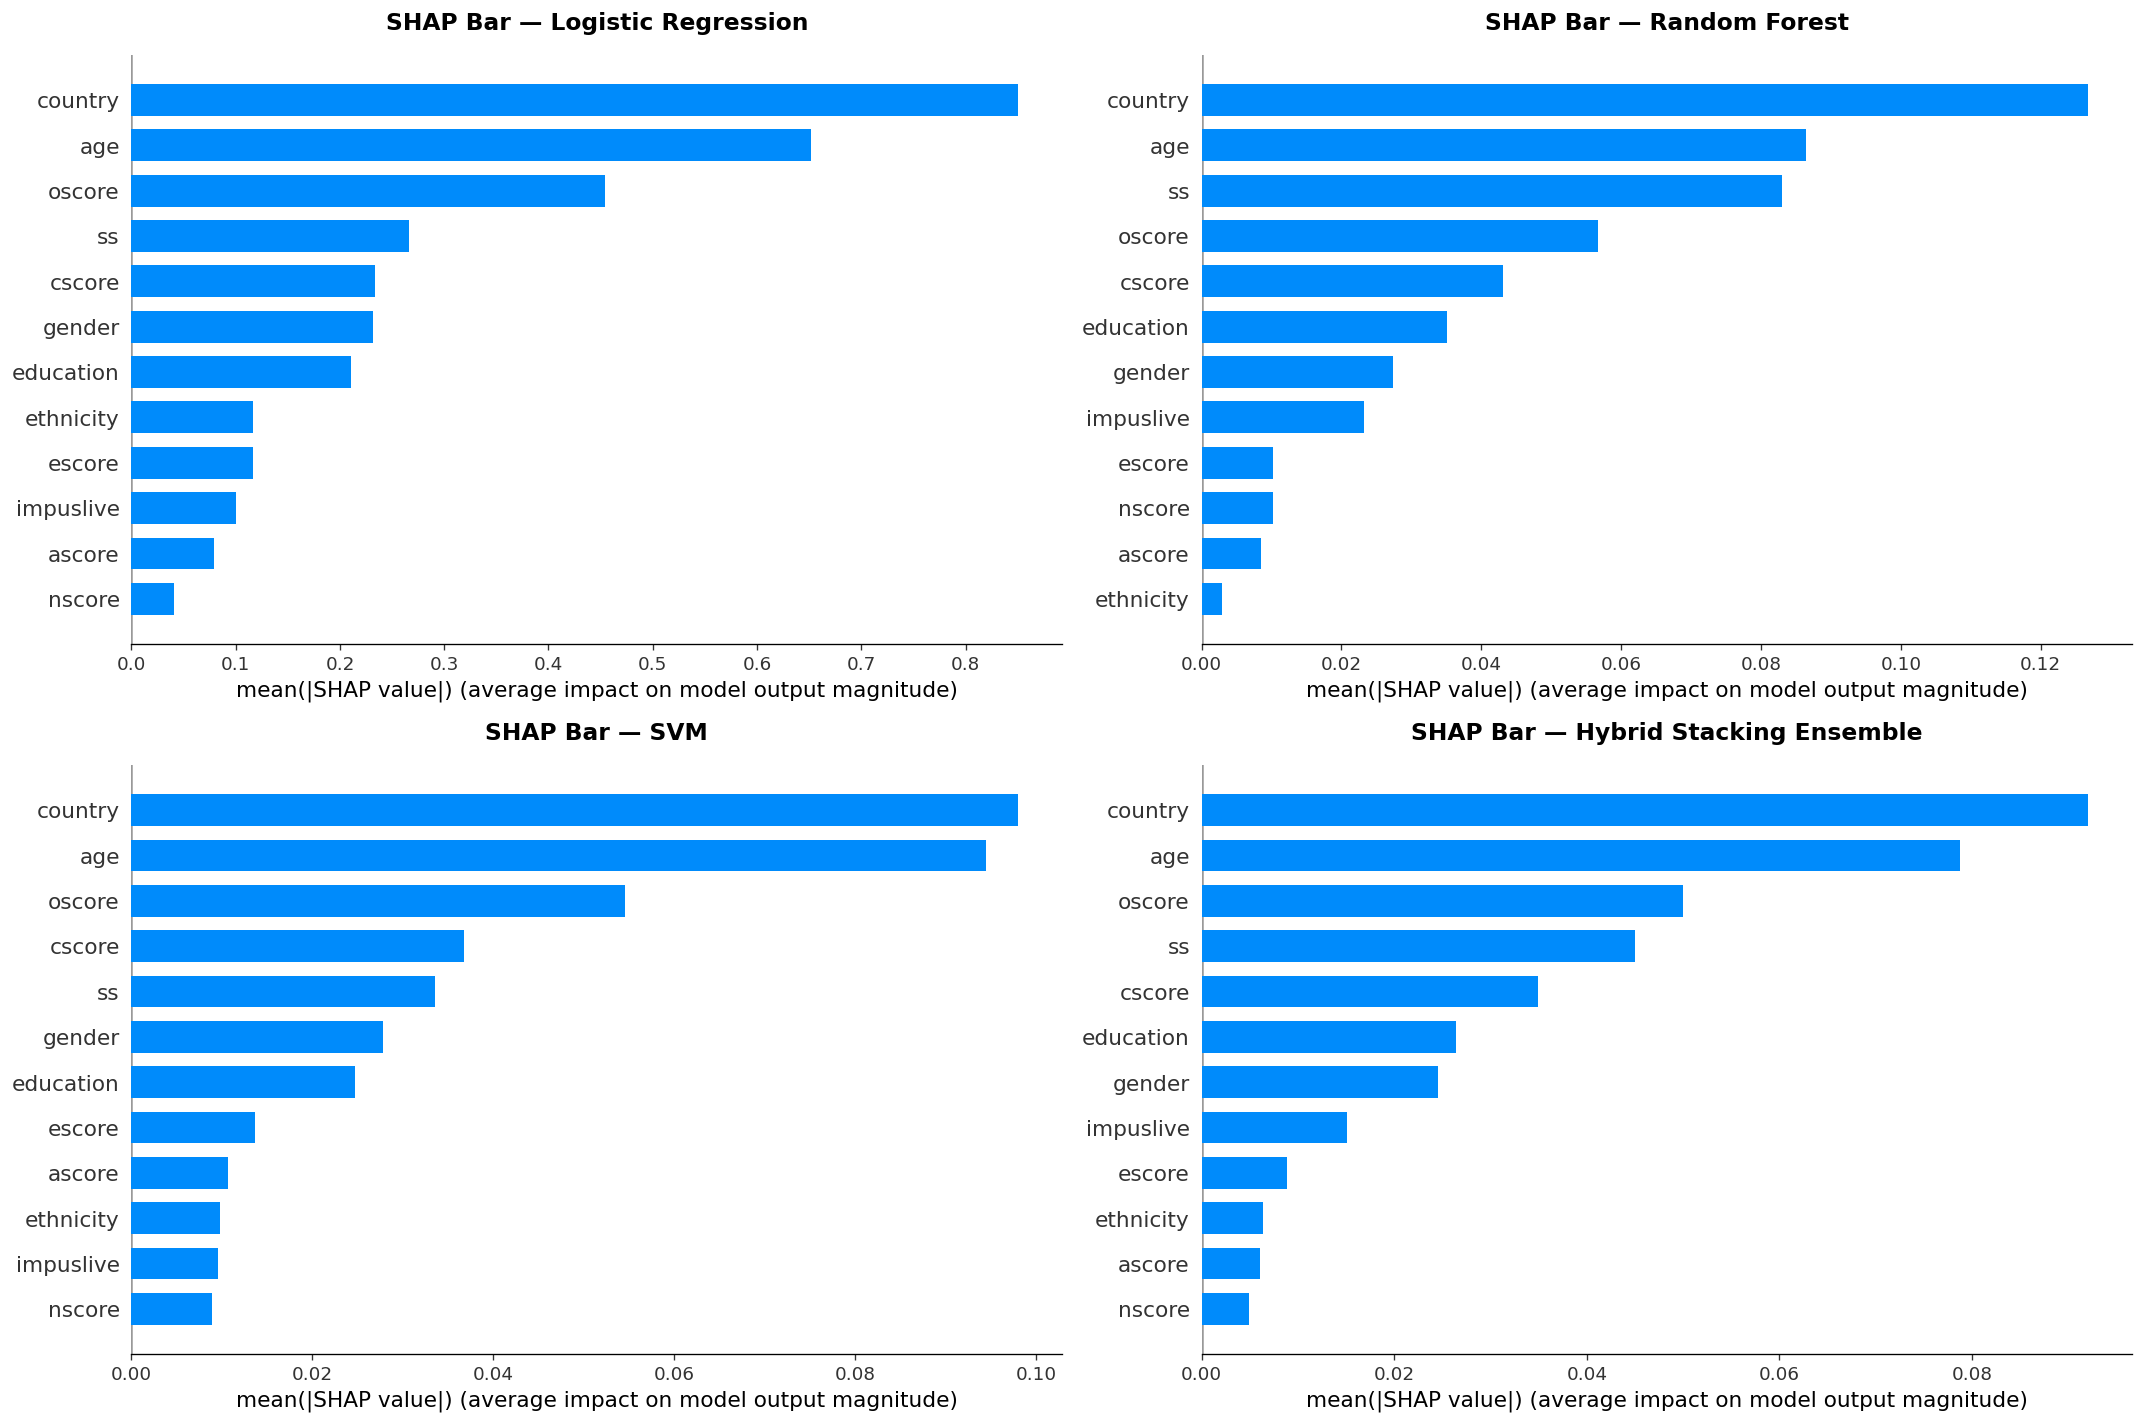

All SHAP bar plots saved successfully!


In [ ]:
# Step 13: SHAP Bar Plot (Baselines + Hybrid Ensemble)

print("\n=== COMPUTING HYBRID ENSEMBLE SHAP VALUES ===")
print("WARNING: KernelExplainer running on a Stacking Ensemble is computationally heavy.")
print("Please wait... this may take a few minutes...")

stacking_predict_func = lambda x: stacking_model.predict_proba(x)[:, 1]

background_stack = shap.sample(pd.DataFrame(X_train_scaled, columns=feature_names), 50)
explainer_stack = shap.KernelExplainer(stacking_predict_func, background_stack)

shap_values_stack = explainer_stack.shap_values(X_sample, nsamples=100)
print("Stacking SHAP values computed!")

print("\n=== GENERATING 2x2 SHAP BAR PLOTS ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
axes = axes.flatten()


plt.sca(axes[0])
shap.summary_plot(shap_values_lr, X_sample, feature_names=feature_names, plot_type='bar', show=False, plot_size=None)
axes[0].set_title('SHAP Bar — Logistic Regression', fontweight='bold', pad=15)


plt.sca(axes[1])
shap.summary_plot(shap_values_rf[:, :, 1], X_sample, feature_names=feature_names, plot_type='bar', show=False, plot_size=None)
axes[1].set_title('SHAP Bar — Random Forest', fontweight='bold', pad=15)


plt.sca(axes[2])
shap.summary_plot(shap_values_svm[:, :, 1], X_sample, feature_names=feature_names, plot_type='bar', show=False, plot_size=None)
axes[2].set_title('SHAP Bar — SVM', fontweight='bold', pad=15)


plt.sca(axes[3])
shap.summary_plot(shap_values_stack, X_sample, feature_names=feature_names, plot_type='bar', show=False, plot_size=None)
axes[3].set_title('SHAP Bar — Hybrid Stacking Ensemble', fontweight='bold', pad=15)

plt.savefig(
    os.path.join(FIG_DIR, 'shap_bar_4_models_including_stack.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("All SHAP bar plots saved successfully!")

## Step 14: SHAP Beeswarm Plot (Baselines + Hybrid Ensemble)



=== GENERATING 2x2 SHAP BEESWARM PLOTS ===


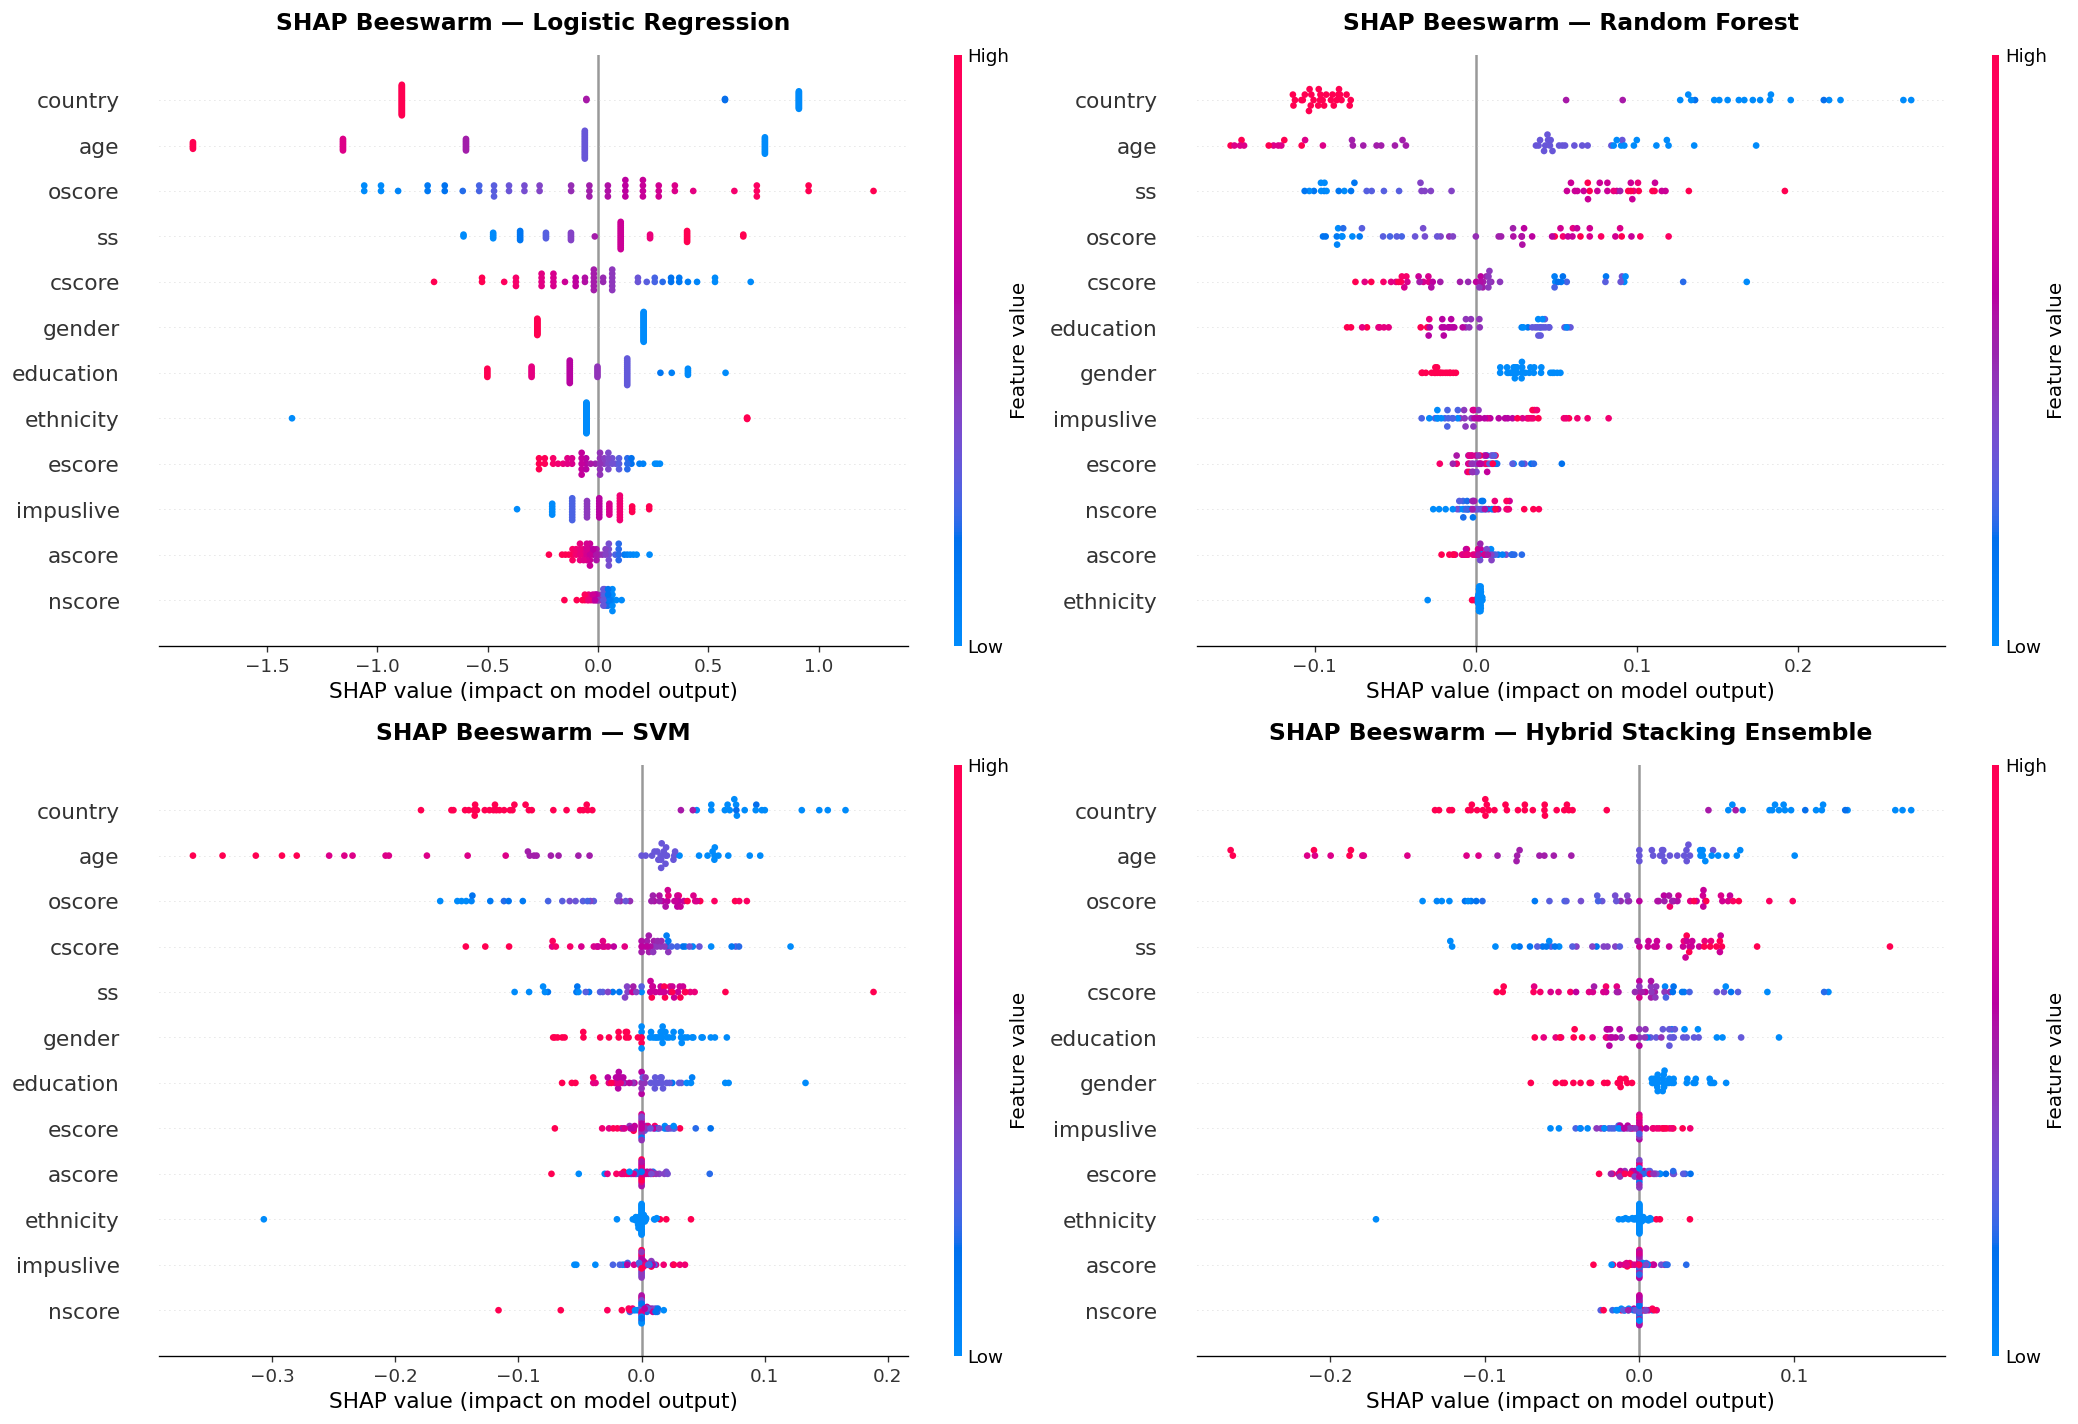

All SHAP beeswarm plots saved successfully!


In [ ]:
## Step 14: SHAP Beeswarm Plot (Baselines + Hybrid Ensemble)

print("\n=== GENERATING 2x2 SHAP BEESWARM PLOTS ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.4)
axes = axes.flatten()

plt.sca(axes[0])
# Omitting plot_type='bar' automatically generates the Beeswarm plot
shap.summary_plot(shap_values_lr, X_sample, feature_names=feature_names, show=False, plot_size=None)
axes[0].set_title('SHAP Beeswarm — Logistic Regression', fontweight='bold', pad=15)

plt.sca(axes[1])
shap.summary_plot(shap_values_rf[:, :, 1], X_sample, feature_names=feature_names, show=False, plot_size=None)
axes[1].set_title('SHAP Beeswarm — Random Forest', fontweight='bold', pad=15)

plt.sca(axes[2])
shap.summary_plot(shap_values_svm[:, :, 1], X_sample, feature_names=feature_names, show=False, plot_size=None)
axes[2].set_title('SHAP Beeswarm — SVM', fontweight='bold', pad=15)

plt.sca(axes[3])
shap.summary_plot(shap_values_stack, X_sample, feature_names=feature_names, show=False, plot_size=None)
axes[3].set_title('SHAP Beeswarm — Hybrid Stacking Ensemble', fontweight='bold', pad=15)

plt.savefig(
    os.path.join(FIG_DIR, 'shap_beeswarm_4_models.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("All SHAP beeswarm plots saved successfully!")

# Step 15: Confusion Matrix Analysis



=== GENERATING CONFUSION MATRICES ===


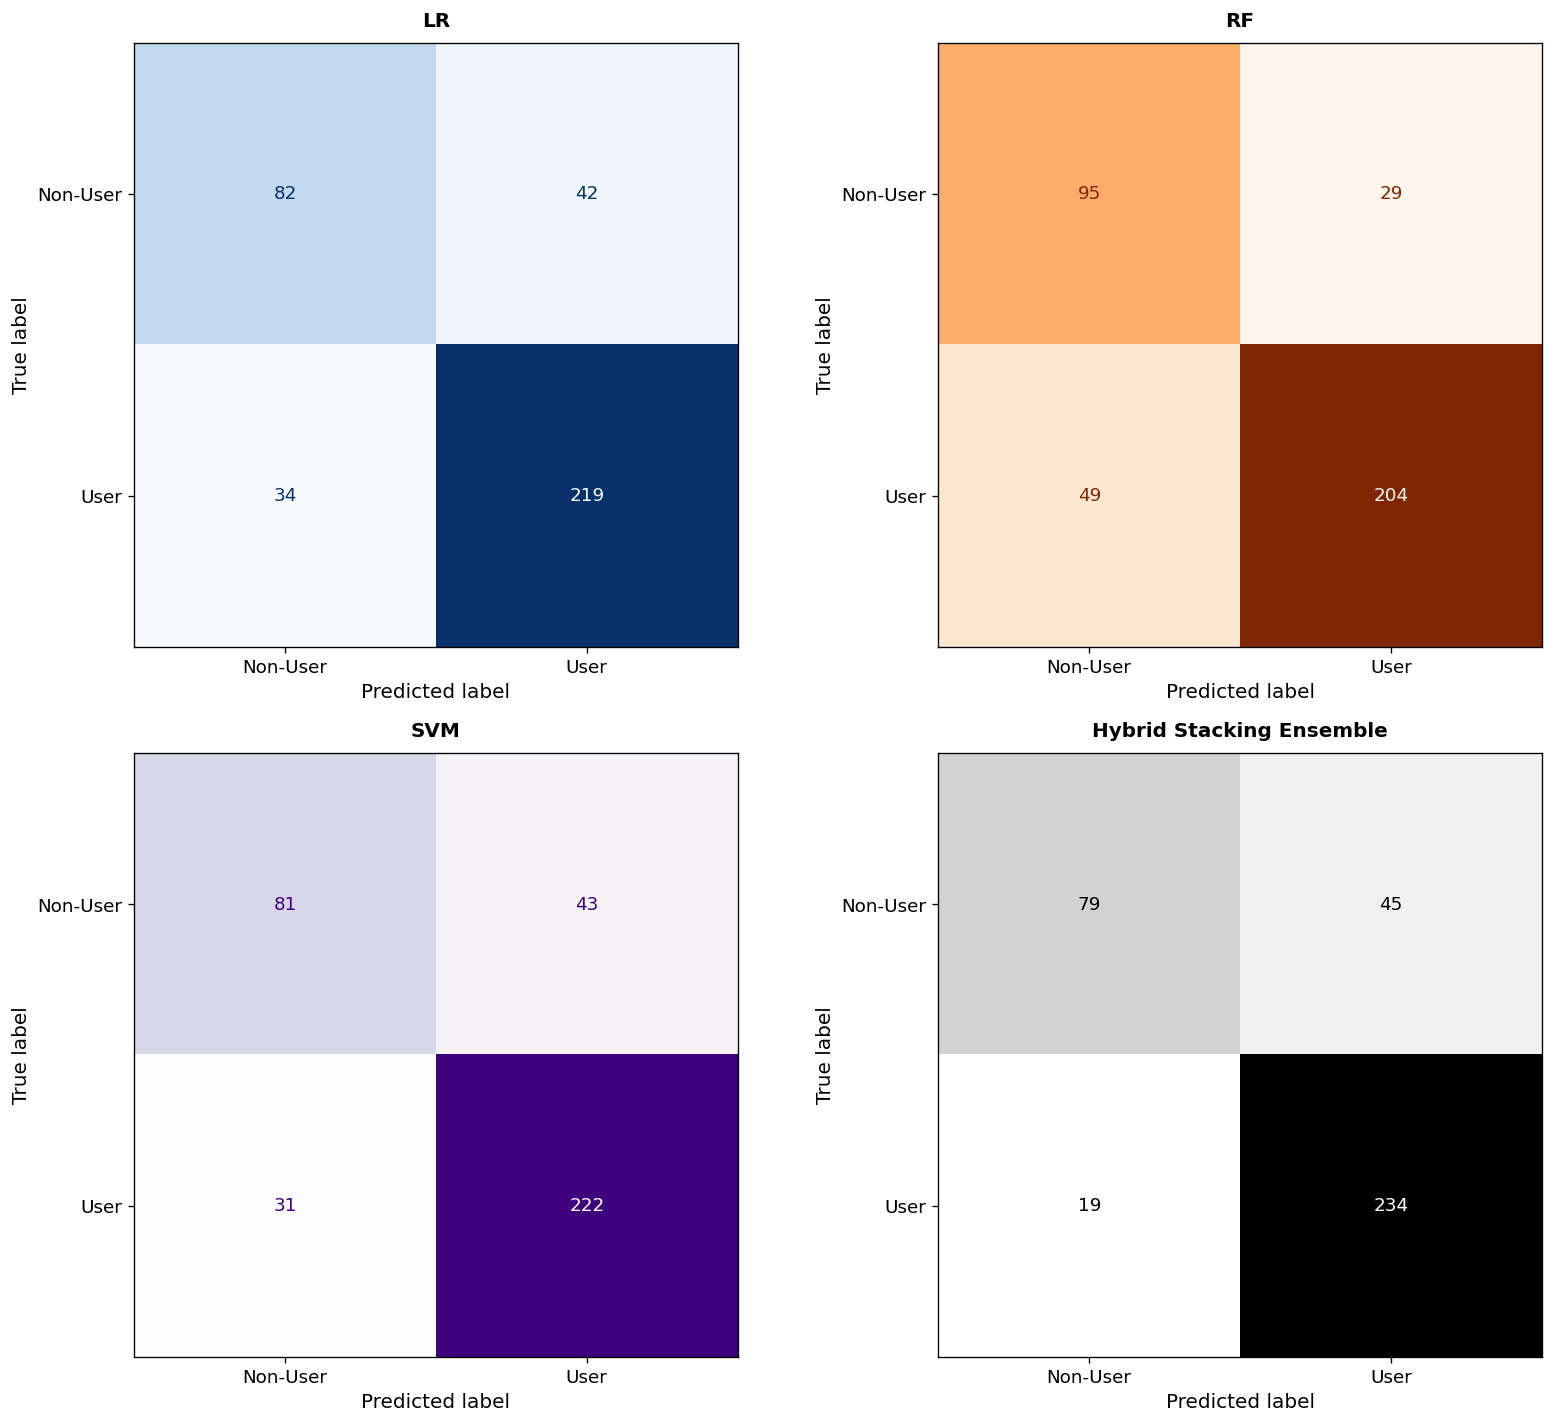

All confusion matrices saved successfully to the figures directory!


In [ ]:
# Step 15: Confusion Matrix Analysis

print("\n=== GENERATING CONFUSION MATRICES ===")

base_preds = {
    'LR': lr_model.predict(X_test_scaled),
    'RF': rf_model.predict(X_test_scaled),
    'SVM': svm_model.predict(X_test_scaled),
    'Hybrid Stacking Ensemble': (
        stacking_model.predict_proba(X_test_scaled)[:, 1] >= optimal_threshold
    ).astype(int)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

plt.subplots_adjust(wspace=0.3, hspace=0.4)

axes = axes.flatten()

colors_base = ['Blues', 'Oranges', 'Purples', 'Greys']

for idx, (name, pred) in enumerate(base_preds.items()):

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-User', 'User']
    )

    disp.plot(
        ax=axes[idx],
        colorbar=False,
        cmap=colors_base[idx]
    )

    axes[idx].set_title(
        name,
        fontweight='bold',
        fontsize=12,
        pad=10
    )

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, 'confusion_matrices_all_models.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("All confusion matrices saved successfully to the figures directory!")

# Step 16: Comprehensive ROC Curve Analysis


=== GENERATING ROC CURVES ===


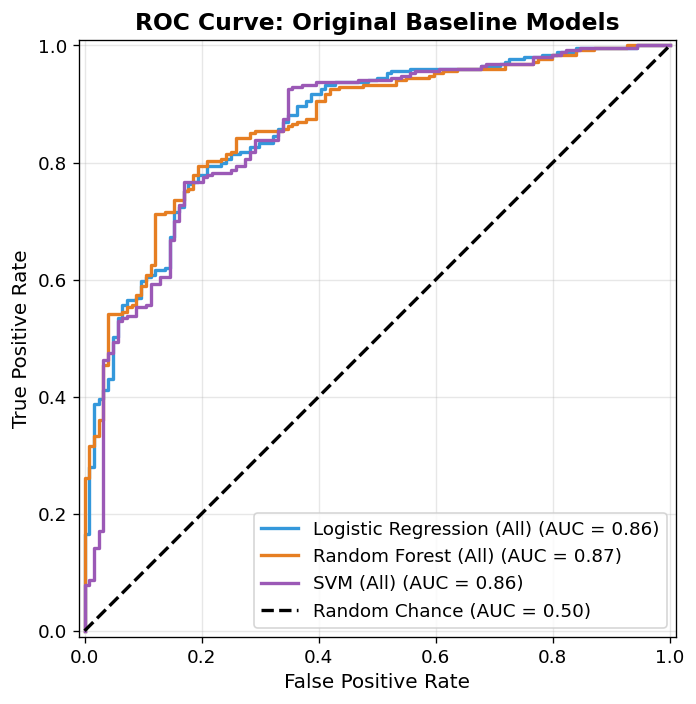

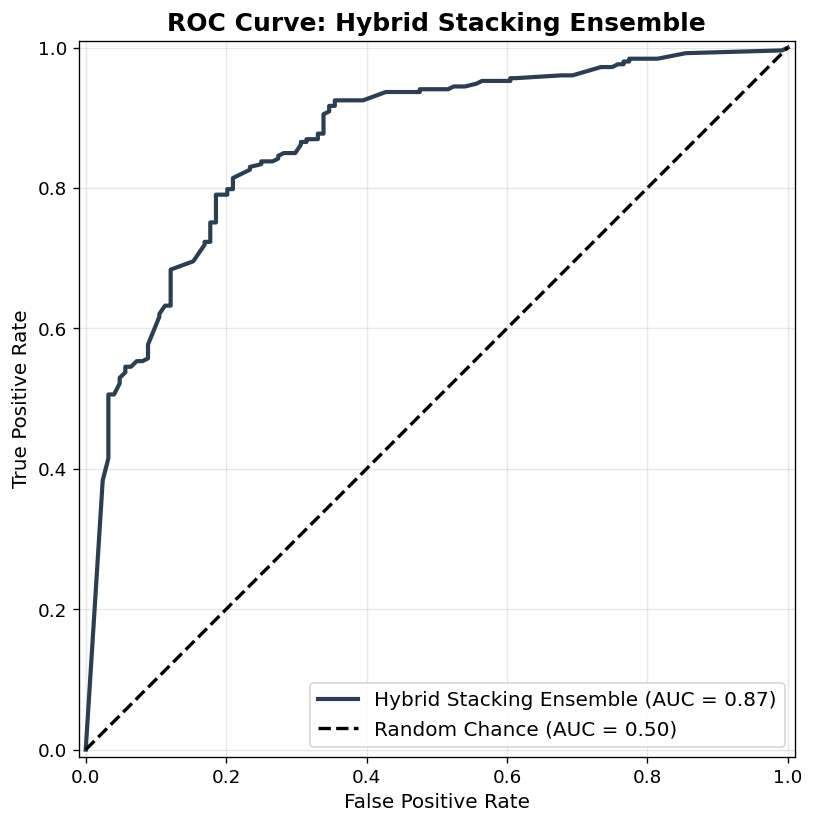

ROC curves successfully generated and saved!


In [ ]:
# Step 16: Comprehensive ROC Curve Analysis

print("\n=== GENERATING ROC CURVES ===")

fig1, ax1 = plt.subplots(figsize=(8, 6))

original_models = {
    'Logistic Regression (All)': lr_model,
    'Random Forest (All)': rf_model,
    'SVM (All)': svm_model
}

colors_orig = ['#3498db', '#e67e22', '#9b59b6']

for idx, (name, model) in enumerate(original_models.items()):

    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        ax=ax1,
        name=name,
        color=colors_orig[idx],
        linewidth=2
    )

ax1.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=2,
    label='Random Chance (AUC = 0.50)'
)

ax1.set_title(
    'ROC Curve: Original Baseline Models',
    fontweight='bold',
    fontsize=14
)

ax1.set_xlabel(
    'False Positive Rate',
    fontsize=12
)

ax1.set_ylabel(
    'True Positive Rate',
    fontsize=12
)

ax1.legend(
    loc='lower right',
    fontsize=11
)

ax1.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, 'roc_curve_1_baselines.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 7))

RocCurveDisplay.from_estimator(
    stacking_model,
    X_test_scaled,
    y_test,
    ax=ax2,
    name='Hybrid Stacking Ensemble',
    color='#2c3e50',
    linewidth=2.5
)

ax2.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=2,
    label='Random Chance (AUC = 0.50)'
)

ax2.set_title(
    'ROC Curve: Hybrid Stacking Ensemble',
    fontweight='bold',
    fontsize=15
)

ax2.set_xlabel(
    'False Positive Rate',
    fontsize=12
)

ax2.set_ylabel(
    'True Positive Rate',
    fontsize=12
)

ax2.legend(
    loc='lower right',
    fontsize=12
)

ax2.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, 'roc_curve_2_stacking.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("ROC curves successfully generated and saved!")

## Step 17: Per-Class Performance Comparison




In [ ]:
# Step 17: Per-Class Performance Comparison
print("\nCALCULATING PER-CLASS PERFORMANCE")

all_predictions = {
    'LR': lr_model.predict(X_test_scaled),
    'RF': rf_model.predict(X_test_scaled),
    'SVM': svm_model.predict(X_test_scaled),

    'Standard Stack': (
        stacking_model.predict_proba(X_test_scaled)[:, 1] >= optimal_threshold
    ).astype(int),
}

results = []

for name, y_pred in all_predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    precision_user = tp / (tp + fp + 1e-10)
    recall_user = tp / (tp + fn + 1e-10)
    f1_user = 2 * (precision_user * recall_user) / (
        precision_user + recall_user + 1e-10
    )

    precision_nonuser = tn / (tn + fn + 1e-10)
    recall_nonuser = tn / (tn + fp + 1e-10)

    results.append({
        'Model': name,
        'User Recall': round(recall_user, 4),
        'User Precision': round(precision_user, 4),
        'User F1': round(f1_user, 4),
        'False Negatives': fn,
        'Non-User Recall': round(recall_nonuser, 4)
    })

per_class_df = pd.DataFrame(results)

# Save to CSV
per_class_df.to_csv(
    os.path.join(TABLE_DIR, "per_class_performance_all_models.csv"),
    index=False
)

print("\n=== PER-CLASS PERFORMANCE (ALL 4 MODELS) ===")
print(per_class_df.to_string(index=False))

print("\nPer-class performance saved to tables!")


CALCULATING PER-CLASS PERFORMANCE

=== PER-CLASS PERFORMANCE (ALL 4 MODELS) ===
         Model  User Recall  User Precision  User F1  False Negatives  Non-User Recall
            LR       0.8656          0.8391   0.8521               34           0.6613
            RF       0.8063          0.8755   0.8395               49           0.7661
           SVM       0.8775          0.8377   0.8571               31           0.6532
Standard Stack       0.9249          0.8387   0.8797               19           0.6371

Per-class performance saved to tables!


# Step 18: Regularization and Complexity Analysis
# (SVM, Logistic Regression, Random Forest, Hybrid Ensemble)


=== REGULARIZATION AND COMPLEXITY ANALYSIS ===
Evaluating SVM and Logistic Regression...
Evaluating Random Forest...
Evaluating Hybrid Stacking Ensemble...


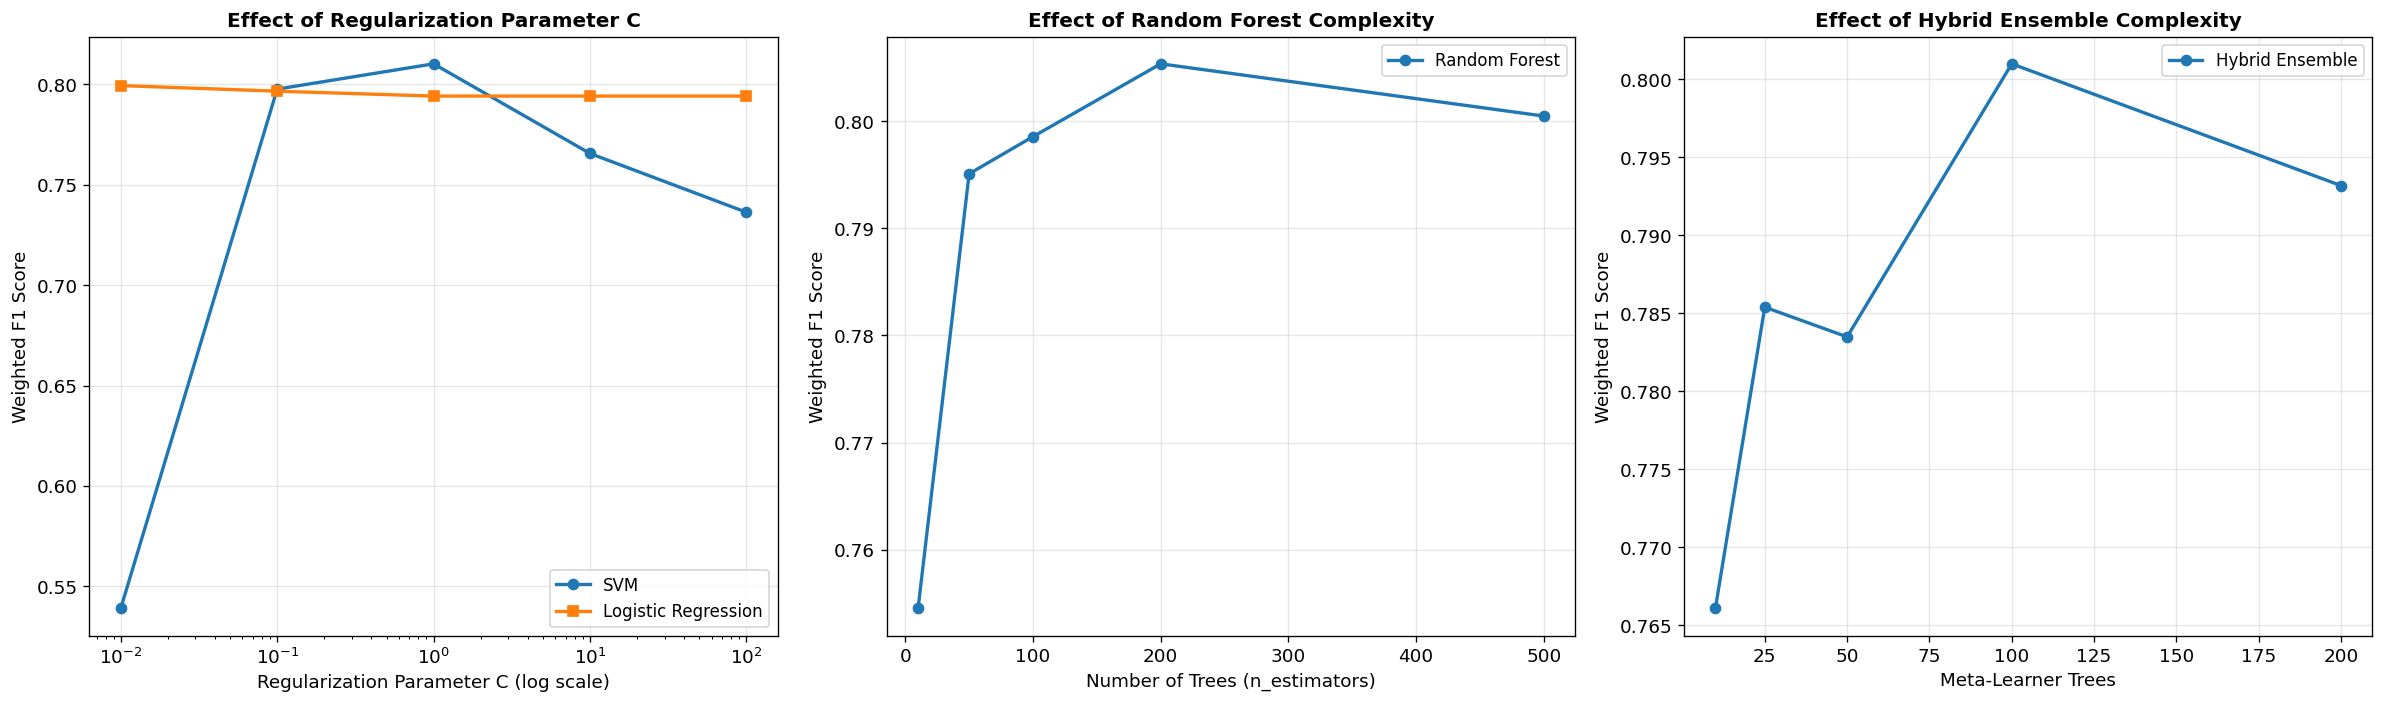


Regularization and complexity analysis completed successfully!


In [ ]:
# Step 18: Regularization and Complexity Analysis
# (SVM, Logistic Regression, Random Forest, Hybrid Ensemble)

print("\n=== REGULARIZATION AND COMPLEXITY ANALYSIS ===")

def evaluate_f1(model, X_train, y_train, X_test, y_test):
    """
    Train model and return weighted F1 score.
    """

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    return f1_score(
        y_test,
        predictions,
        average='weighted'
    )

# 1. SVM and Logistic Regressio Effect of Regularization Parameter C

C_values = [0.01, 0.1, 1, 10, 100]

svm_f1_scores = []
lr_f1_scores = []

print("Evaluating SVM and Logistic Regression...")

for C in C_values:

    svm_model_c = SVC(
        kernel='rbf',
        C=C,
        probability=True,
        random_state=42
    )
    lr_model_c = LogisticRegression(
        C=C,
        max_iter=5000,
        random_state=42
    )
    svm_f1_scores.append(
        evaluate_f1(
            svm_model_c,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )
    )
    lr_f1_scores.append(
        evaluate_f1(
            lr_model_c,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )
    )
# 2. Random Forest Effect of Number of Trees

rf_tree_values = [10, 50, 100, 200, 500]
rf_f1_scores = []
print("Evaluating Random Forest...")

for trees in rf_tree_values:

    rf_model_t = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    rf_f1_scores.append(
        evaluate_f1(
            rf_model_t,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )
    )

# 3. Hybrid Ensemble Complexity Analysis
meta_estimators = [10, 25, 50, 100, 200]
hybrid_f1_scores = []

print("Evaluating Hybrid Stacking Ensemble...")

for n_est in meta_estimators:

    hybrid_meta = RandomForestClassifier(
        n_estimators=n_est,
        random_state=42
    )
    hybrid_stack = StackingClassifier(
        estimators=[
            ('lr', lr_model),
            ('rf', rf_model),
            ('svm', svm_model)
        ],
        final_estimator=hybrid_meta,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1
    )
    hybrid_f1_scores.append(
        evaluate_f1(
            hybrid_stack,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )
    )
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)
plt.subplots_adjust(wspace=0.30)

axes[0].plot(
    C_values,
    svm_f1_scores,
    marker='o',
    linewidth=2,
    label='SVM'
)
axes[0].plot(
    C_values,
    lr_f1_scores,
    marker='s',
    linewidth=2,
    label='Logistic Regression'
)
axes[0].set_xscale('log')
axes[0].set_xlabel(
    'Regularization Parameter C (log scale)',
    fontsize=11
)
axes[0].set_ylabel(
    'Weighted F1 Score',
    fontsize=11
)
axes[0].set_title(
    'Effect of Regularization Parameter C',
    fontsize=12,
    fontweight='bold'
)
axes[0].legend()
axes[0].grid(alpha=0.3)


axes[1].plot(
    rf_tree_values,
    rf_f1_scores,
    marker='o',
    linewidth=2,
    label='Random Forest'
)
axes[1].set_xlabel(
    'Number of Trees (n_estimators)',
    fontsize=11
)
axes[1].set_ylabel(
    'Weighted F1 Score',
    fontsize=11
)
axes[1].set_title(
    'Effect of Random Forest Complexity',
    fontsize=12,
    fontweight='bold'
)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(
    meta_estimators,
    hybrid_f1_scores,
    marker='o',
    linewidth=2,
    label='Hybrid Ensemble'
)

axes[2].set_xlabel(
    'Meta-Learner Trees',
    fontsize=11
)

axes[2].set_ylabel(
    'Weighted F1 Score',
    fontsize=11
)

axes[2].set_title(
    'Effect of Hybrid Ensemble Complexity',
    fontsize=12,
    fontweight='bold'
)

axes[2].legend()

axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        'regularization_complexity_analysis_final.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nRegularization and complexity analysis completed successfully!")